<a href="https://colab.research.google.com/github/xiaann622/Analystlab/blob/Week-6/AAPL_Stock_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AAPL Stock Market Data Analysis
### Data Transformation, Time-Series Analysis & Feature Engineering with Pandas

**Objective:** Apply advanced Pandas techniques, time-series methods, and feature engineering to Apple Inc. (AAPL) historical stock market data.

**Dataset:** Apple Inc. (AAPL) daily historical prices — Open, High, Low, Close, Adjusted Close, Volume.
**Primary source:** [Yahoo Finance — AAPL Historical Data](https://finance.yahoo.com/quote/AAPL/history/), retrieved programmatically via the `yfinance` Python library (Aroussi, *yfinance*, PyPI: https://pypi.org/project/yfinance/).

**Analysis window:** a rolling 5-year lookback ending on the day the notebook is run.

---
**How data loading works in this notebook:** Section 2 first attempts a **live pull** from Yahoo Finance via `yfinance`. If the live pull fails — for example, no internet access, or the endpoint being unreachable from a locked-down/offline environment — it automatically falls back to a **local cached CSV snapshot** (`aapl_data.csv`) so the rest of the notebook still runs end-to-end. This live-then-cache pattern is a simple version of the kind of resilient data pipeline used in production data engineering.


##**1. SETUP**

In [1]:
# Install the yfinance library (safe to re-run; no-ops if already installed)
!pip install -q yfinance

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta

%matplotlib inline
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13

print(f"pandas {pd.__version__} | numpy {np.__version__} | yfinance {yf.__version__} | seaborn {sns.__version__}")

pandas 2.2.3 | numpy 2.1.3 | yfinance 0.2.66 | seaborn 0.13.2


## 2. Data Loading

We pull the most recent 5 years of AAPL daily OHLCV data. `auto_adjust=False` is set deliberately so Yahoo Finance returns **Close** and **Adjusted Close** as two distinct columns, matching the dataset schema required for this task.

In [3]:
TICKER = "AAPL"
YEARS_OF_HISTORY = 5
CACHE_FILE = "aapl_data.csv"

end_date = datetime.today()
start_date = end_date - timedelta(days=365 * YEARS_OF_HISTORY)

try:
    raw = yf.download(
        TICKER,
        start=start_date.strftime("%Y-%m-%d"),
        end=end_date.strftime("%Y-%m-%d"),
        auto_adjust=False,   # keep Close and Adj Close as separate columns
        progress=False,
    )
    if raw.empty:
        raise ValueError("Empty response from Yahoo Finance")
    # Recent yfinance versions return MultiIndex columns like ('Close', 'AAPL') for a single ticker
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw = raw.reset_index()
    raw.to_csv(CACHE_FILE, index=False)   # refresh local cache for next time / reproducibility
    data_source = "live pull from Yahoo Finance via yfinance"
except Exception as e:
    print(f"Live download unavailable ({e.__class__.__name__}: {e}).")
    print(f"Falling back to cached local snapshot: {CACHE_FILE}")
    raw = pd.read_csv(CACHE_FILE, parse_dates=["Date"])
    data_source = f"cached snapshot ({CACHE_FILE})"

print(f"\nData source used : {data_source}")
print(f"Rows loaded      : {len(raw):,}")
print(f"Date range       : {raw['Date'].min().date()}  to  {raw['Date'].max().date()}")
raw.head()


Data source used : live pull from Yahoo Finance via yfinance
Rows loaded      : 1,254
Date range       : 2021-08-23  to  2026-08-20


Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-08-23,146.022797,149.710007,150.190002,147.889999,148.309998,60131800
1,2021-08-24,145.935028,149.619995,150.860001,149.149994,149.449997,48606400
2,2021-08-25,144.706085,148.360001,150.320007,147.800003,149.809998,58991300
3,2021-08-26,143.906250,147.539993,149.119995,147.509995,148.350006,48597200
4,2021-08-27,144.940155,148.600006,148.750000,146.830002,147.479996,55802400


## 3. Initial Data Exploration

In [4]:
df = raw.copy()
print("Column dtypes:")
print(df.dtypes)
print(f"\nShape: {df.shape}")
df.describe().round(2)

Column dtypes:
Price
Date         datetime64[ns]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
dtype: object

Shape: (1254, 7)


Price,Date,Adj Close,Close,High,Low,Open,Volume
count,1254,1254.00,1254.00,1254.00,1254.00,1254.00,1.254000e+03
mean,2024-02-19 10:01:43.349282304,198.56,200.62,202.62,198.42,200.40,6.445054e+07
min,2021-08-23 00:00:00,122.83,125.02,127.77,124.17,126.01,1.791060e+07
25%,2022-11-17 06:00:00,160.99,164.06,165.72,161.93,163.84,4.533010e+07
50%,2024-02-20 12:00:00,186.96,189.33,190.33,187.46,189.08,5.602290e+07
75%,2025-05-20 18:00:00,230.77,232.15,233.46,229.34,231.44,7.615540e+07
max,2026-08-20 00:00:00,339.79,340.08,344.57,337.35,340.03,3.186799e+08
std,NaN,48.37,47.50,47.87,47.05,47.42,2.860586e+07


In [5]:
print("Missing values per column:")
print(df.isna().sum())
print(f"\nExact duplicate rows : {df.duplicated().sum()}")
print(f"Duplicate dates      : {df['Date'].duplicated().sum()}")
print(f"Any non-positive OHLC prices? "
      f"{(df[['Open','High','Low','Close','Adj Close']] <= 0).any().any()}")

Missing values per column:
Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Exact duplicate rows : 0
Duplicate dates      : 0
Any non-positive OHLC prices? False


**Observation:** Because AAPL is one of the most heavily traded, mega-cap stocks on the market, Yahoo Finance's raw OHLCV feed for it is essentially complete — no missing values, no duplicate trading days, no non-positive prices. This is *not* true of every ticker (thinly traded stocks and older listings often have real gaps), so the cleaning steps below are still implemented as general-purpose, defensive code. Section 4.2 also demonstrates a missing-value scenario that **is** genuinely present in this data: calendar-day gaps from weekends and market holidays.

## 4. Data Cleaning & Preprocessing

### 4.1 Standardize types, sort, index by date

In [6]:
df = df.sort_values('Date').drop_duplicates(subset='Date').reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

df = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].astype({
    'Open': 'float64', 'High': 'float64', 'Low': 'float64',
    'Close': 'float64', 'Adj Close': 'float64', 'Volume': 'int64'
})

print(f"Clean, sorted, de-duplicated frame: {df.shape[0]} trading days")
df.head(3)

Clean, sorted, de-duplicated frame: 1254 trading days


Price,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-08-23,148.309998,150.190002,147.889999,149.710007,146.022797,60131800
2021-08-24,149.449997,150.860001,149.149994,149.619995,145.935028,48606400
2021-08-25,149.809998,150.320007,147.800003,148.360001,144.706085,58991300


### 4.2 Handling missing values (calendar-day gap demonstration)

In [7]:
# Reindexing to EVERY calendar day (not just trading days) exposes real gaps: weekends & market holidays
calendar_index = pd.date_range(df.index.min(), df.index.max(), freq='D')
calendar_df = df.reindex(calendar_index)

n_gaps = calendar_df['Close'].isna().sum()
print(f"Reindexing to daily calendar frequency introduces {n_gaps} NaN rows "
      f"({n_gaps/len(calendar_df):.1%} of calendar days) — these are non-trading days, not data errors.")

# Standard finance-data practice: forward-fill non-trading days for calendar-based joins/reporting
calendar_df_filled = calendar_df.ffill()
print(f"After forward-fill, remaining NaNs: {calendar_df_filled['Close'].isna().sum()}")

Reindexing to daily calendar frequency introduces 570 NaN rows (31.2% of calendar days) — these are non-trading days, not data errors.
After forward-fill, remaining NaNs: 0


## 5. Data Transformation with Pandas

### 5.1 Calculated columns

In [8]:
df['Daily_Change'] = df['Adj Close'].diff()
df['Daily_Return_%'] = df['Adj Close'].pct_change() * 100
df['High_Low_Spread'] = df['High'] - df['Low']
df['Price_Range_%'] = (df['High'] - df['Low']) / df['Open'] * 100

df[['Adj Close', 'Daily_Change', 'Daily_Return_%', 'High_Low_Spread', 'Price_Range_%']].tail()

Price,Adj Close,Daily_Change,Daily_Return_%,High_Low_Spread,Price_Range_%
Date,,,,,
2026-08-14,305.929993,0.669983,0.219479,3.190002,1.042484
2026-08-17,305.589996,-0.339996,-0.111135,4.720001,1.541426
2026-08-18,310.029999,4.440002,1.452928,5.750000,1.869432
2026-08-19,316.829987,6.799988,2.193332,9.679993,3.121169
2026-08-20,311.299988,-5.529999,-1.745415,9.630005,3.033455


### 5.2 Filtering & sorting

In [9]:
big_moves = df[df['Daily_Return_%'].abs() >= 5].sort_values('Daily_Return_%')
print(f"Trading days with a single-day move of ±5% or more: {len(big_moves)}")
big_moves[['Adj Close', 'Daily_Return_%', 'Volume']]

Trading days with a single-day move of ±5% or more: 16


Price,Adj Close,Daily_Return_%,Volume
Date,,,
2025-04-03,201.947876,-9.245604,103419000
2026-07-31,308.643829,-7.353858,132489100
2025-04-04,187.228424,-7.288738,125910900
2026-06-25,274.912903,-6.117774,107013700
2022-09-13,150.891876,-5.867973,122656600
2022-05-18,137.929794,-5.641972,109742900
2022-05-05,153.327225,-5.571616,130525300
2022-05-11,143.493301,-5.184105,142689800
2025-08-06,212.224304,5.090679,108483100


In [10]:
# Top 10 highest-volume trading days
df.sort_values('Volume', ascending=False).head(10)[['Adj Close', 'Volume', 'Daily_Return_%']]

Price,Adj Close,Volume,Daily_Return_%
Date,,,
2024-09-20,226.306900,318679900,-0.292730
2026-06-26,283.535461,261775500,3.136469
2024-06-21,205.530792,241805100,-1.044459
2024-06-12,211.058136,198134300,2.857842
2021-12-17,167.168655,195432700,-0.650162
2025-04-09,197.634399,184395900,15.328861
2022-05-12,139.634140,182602000,-2.689437
2022-01-28,166.377472,179935700,6.977775
2021-11-30,161.464157,174048100,3.157774


### 5.3 Grouping & aggregation

In [11]:
df['Year'] = df.index.year
df['Month'] = df.index.month

yearly_summary = df.groupby('Year').agg(
    Avg_Close=('Adj Close', 'mean'),
    Start_Close=('Adj Close', 'first'),
    End_Close=('Adj Close', 'last'),
    Total_Volume=('Volume', 'sum'),
    Avg_Daily_Return_pct=('Daily_Return_%', 'mean'),
).round(2)
yearly_summary['Yearly_Return_%'] = ((yearly_summary['End_Close'] / yearly_summary['Start_Close']) - 1) * 100
yearly_summary

,Avg_Close,Start_Close,End_Close,Total_Volume,Avg_Daily_Return_pct,Yearly_Return_%
Year,,,,,,
2021,151.47,146.02,173.45,7948248900,0.20,18.785098
2022,151.67,177.79,127.65,22065504500,-0.10,-28.201811
2023,170.05,122.88,190.21,14805886900,0.17,54.793294
2024,205.28,183.40,248.62,14390908500,0.12,35.561614
2025,231.15,242.09,271.12,13543944600,0.06,11.991408
2026,282.74,270.27,311.30,8066483400,0.10,15.181115


### 5.4 Restructuring (pivot table)

In [12]:
pivot_close = df.pivot_table(values='Adj Close', index='Year', columns='Month', aggfunc='mean').round(2)
pivot_close

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,146.14,144.65,141.98,150.64,169.53
2022,165.92,166.07,161.68,163.16,145.34,136.93,146.60,163.65,150.07,142.23,143.25,135.46
2023,133.40,148.46,152.48,162.40,169.99,181.58,189.59,178.58,174.64,172.34,183.56,191.97
2024,185.46,182.71,170.83,167.78,184.45,204.32,222.48,219.72,221.90,228.15,226.11,247.53
2025,232.90,236.99,221.34,199.95,202.88,199.69,210.26,223.75,241.59,257.34,270.85,275.56
2026,256.95,268.63,254.45,264.22,297.21,296.16,322.01,308.47,NaN,NaN,NaN,NaN


## 6. Time-Series Analysis

### 6.1 Monthly resampling & returns

In [13]:
monthly_close = df['Adj Close'].resample('ME').last()
monthly_returns = monthly_close.pct_change().dropna() * 100

print(f"Complete calendar months in the sample: {len(monthly_returns)}")
monthly_returns.tail()

Complete calendar months in the sample: 60


,Adj Close
Date,
2026-04-30,6.919118
2026-05-31,15.108715
2026-06-30,-7.274245
2026-07-31,6.756296
2026-08-31,0.860590


### 6.2 Rolling (moving) averages

In [14]:
df['MA_7'] = df['Adj Close'].rolling(window=7).mean()
df['MA_30'] = df['Adj Close'].rolling(window=30).mean()
df['MA_90'] = df['Adj Close'].rolling(window=90).mean()

df[['Adj Close', 'MA_7', 'MA_30', 'MA_90']].tail()

Price,Adj Close,MA_7,MA_30,MA_90
Date,,,,
2026-08-14,305.929993,307.401546,318.552157,298.324812
2026-08-17,305.589996,306.465716,318.325470,298.848715
2026-08-18,310.029999,306.032859,318.313393,299.404315
2026-08-19,316.829987,307.257141,318.437061,300.035582
2026-08-20,311.299988,308.169996,318.282143,300.619601


### 6.3 Cumulative return & rolling volatility

In [15]:
df['Cumulative_Return_%'] = (df['Adj Close'] / df['Adj Close'].iloc[0] - 1) * 100

df['Rolling_Volatility_30_%'] = df['Adj Close'].pct_change().rolling(30).std() * np.sqrt(252) * 100

df[['Cumulative_Return_%', 'Rolling_Volatility_30_%']].describe().round(2)

Price,Cumulative_Return_%,Rolling_Volatility_30_%
count,1254.00,1224.00
mean,35.98,26.36
std,33.13,9.99
min,-15.88,10.24
25%,10.25,19.94
50%,28.03,24.63
75%,58.04,29.85
max,132.69,70.01


## 7. Feature Engineering

Mapping each month's aggregate return back onto every daily row (a common feature-engineering pattern: attaching a period-level statistic to row-level data).

In [16]:
month_return_map = monthly_returns.copy()
month_return_map.index = month_return_map.index.to_period('M')
df['Month_Period'] = df.index.to_period('M')
df['Monthly_Return_%'] = df['Month_Period'].map(month_return_map)
df = df.drop(columns='Month_Period')

feature_cols = ['Adj Close', 'Daily_Change', 'Daily_Return_%', 'MA_7', 'MA_30', 'MA_90',
                 'Cumulative_Return_%', 'Rolling_Volatility_30_%', 'Monthly_Return_%',
                 'High_Low_Spread', 'Price_Range_%']
df[feature_cols].tail(10).round(2)

Price,Adj Close,Daily_Change,Daily_Return_%,MA_7,MA_30,MA_90,Cumulative_Return_%,Rolling_Volatility_30_%,Monthly_Return_%,High_Low_Spread,Price_Range_%
Date,,,,,,,,,,,
2026-08-07,313.06,0.92,0.29,312.86,316.22,295.53,114.39,35.76,0.86,4.07,1.31
2026-08-10,308.26,-4.80,-1.53,309.30,317.04,296.14,111.10,35.28,0.86,3.65,1.19
2026-08-11,304.91,-3.35,-1.09,308.77,317.82,296.70,108.81,35.39,0.86,7.18,2.33
2026-08-12,302.25,-2.66,-0.87,308.64,318.26,297.22,106.99,34.79,0.86,5.09,1.67
2026-08-13,305.26,3.01,1.00,308.09,318.63,297.74,109.05,34.56,0.86,3.95,1.30
2026-08-14,305.93,0.67,0.22,307.40,318.55,298.32,109.51,31.57,0.86,3.19,1.04
2026-08-17,305.59,-0.34,-0.11,306.47,318.33,298.85,109.28,31.33,0.86,4.72,1.54
2026-08-18,310.03,4.44,1.45,306.03,318.31,299.40,112.32,31.58,0.86,5.75,1.87
2026-08-19,316.83,6.80,2.19,307.26,318.44,300.04,116.97,32.11,0.86,9.68,3.12


**Engineered feature summary**

| Feature | Description |
|---|---|
| `Daily_Change` | Day-over-day change in Adjusted Close, in USD |
| `Daily_Return_%` | Day-over-day percentage change |
| `MA_7` / `MA_30` / `MA_90` | 7 / 30 / 90-day simple moving averages |
| `Cumulative_Return_%` | Total return since the start of the window |
| `Rolling_Volatility_30_%` | 30-day rolling annualized volatility |
| `Monthly_Return_%` | Return of the calendar month, mapped to every day in that month |
| `High_Low_Spread` | Intraday High − Low, in USD |
| `Price_Range_%` | Intraday High − Low as a % of Open |


## 8. Visualizations

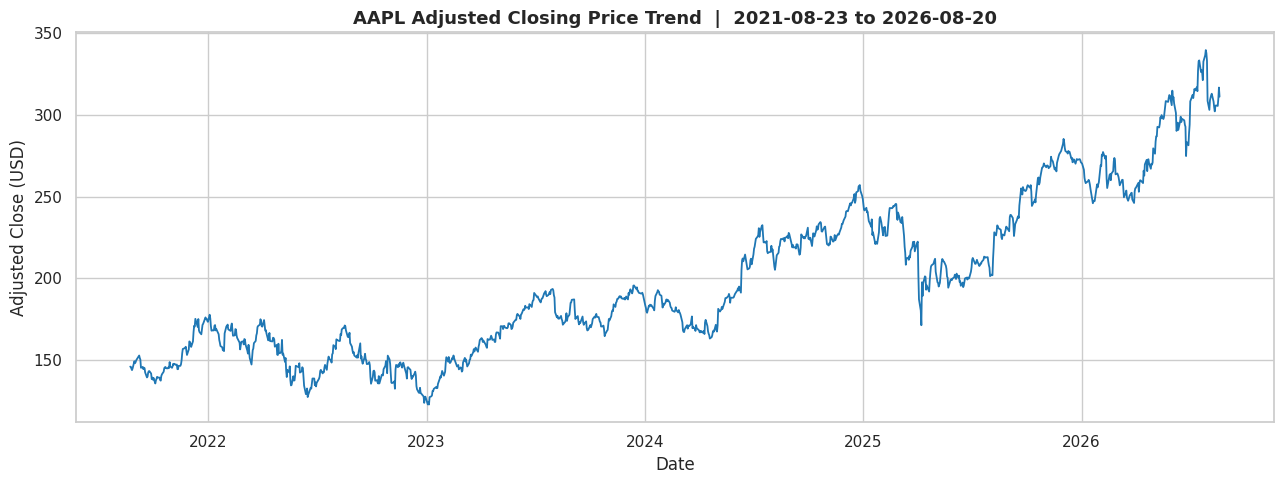

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df['Adj Close'], color='#1f77b4', linewidth=1.3)
ax.set_title(f"AAPL Adjusted Closing Price Trend  |  {df.index.min().date()} to {df.index.max().date()}")
ax.set_xlabel('Date'); ax.set_ylabel('Adjusted Close (USD)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('viz1_closing_price_trend.png', dpi=120)
plt.show()

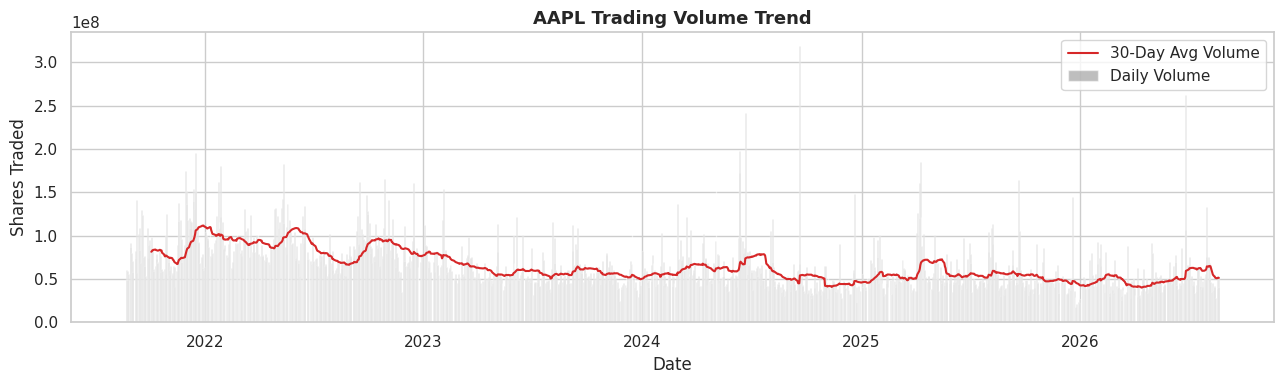

In [18]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(df.index, df['Volume'], width=1.5, color='#7f7f7f', alpha=0.5, label='Daily Volume')
ax.plot(df.index, df['Volume'].rolling(30).mean(), color='#d62728', linewidth=1.5, label='30-Day Avg Volume')
ax.set_title('AAPL Trading Volume Trend')
ax.set_xlabel('Date'); ax.set_ylabel('Shares Traded')
ax.legend()
plt.tight_layout()
plt.savefig('viz2_volume_trend.png', dpi=120)
plt.show()

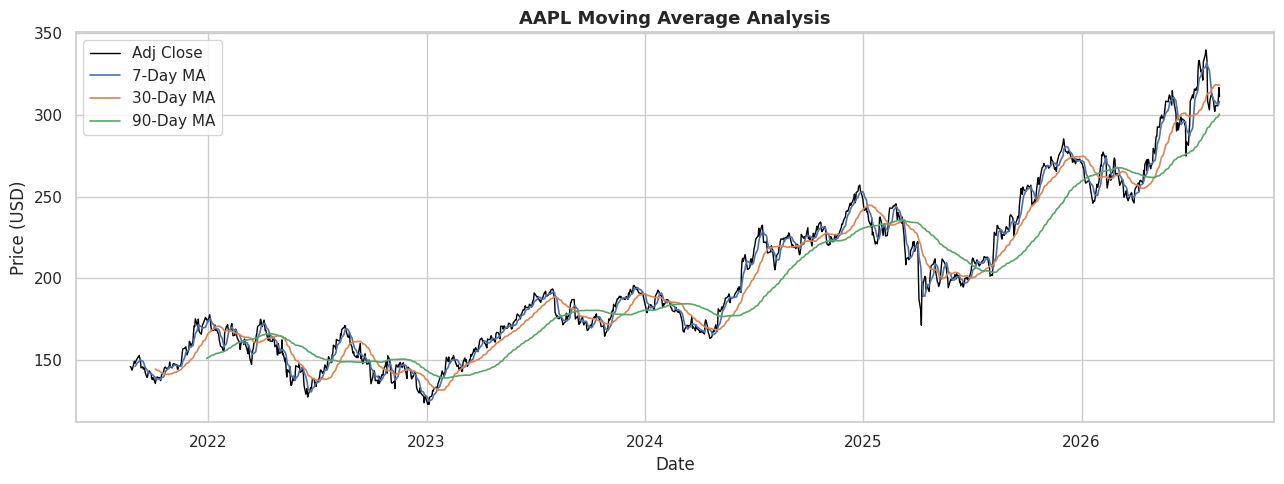

In [19]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df['Adj Close'], label='Adj Close', color='black', linewidth=1)
ax.plot(df.index, df['MA_7'], label='7-Day MA', linewidth=1.2)
ax.plot(df.index, df['MA_30'], label='30-Day MA', linewidth=1.2)
ax.plot(df.index, df['MA_90'], label='90-Day MA', linewidth=1.2)
ax.set_title('AAPL Moving Average Analysis')
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('viz3_moving_averages.png', dpi=120)
plt.show()

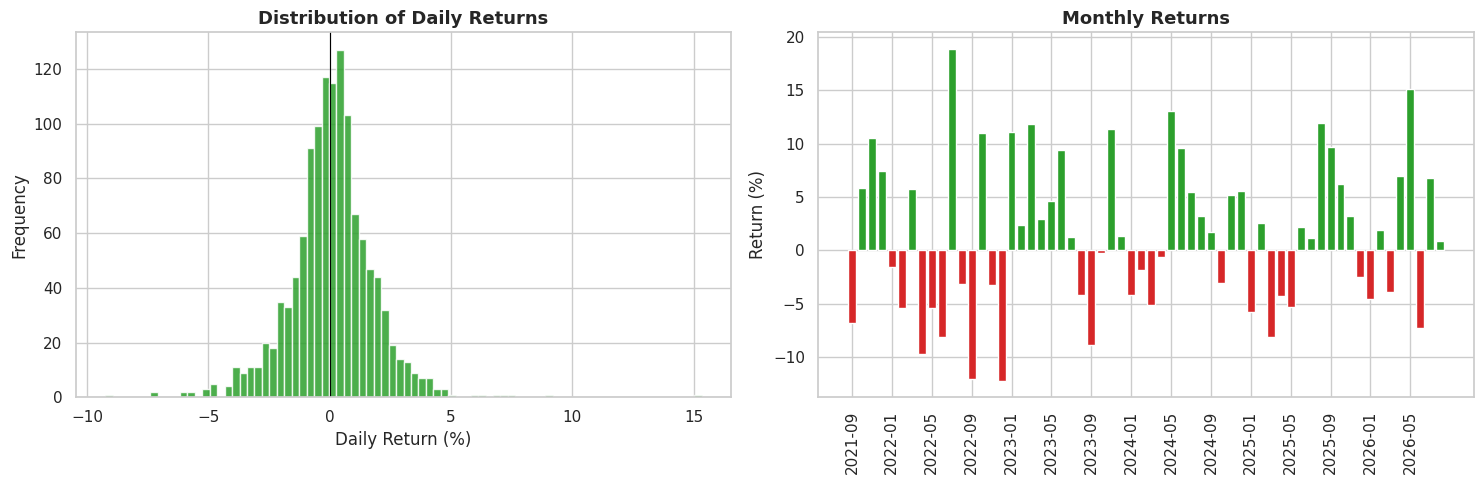

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['Daily_Return_%'].dropna(), bins=80, color='#2ca02c', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Distribution of Daily Returns')
axes[0].set_xlabel('Daily Return (%)'); axes[0].set_ylabel('Frequency')

colors = ['#2ca02c' if v >= 0 else '#d62728' for v in monthly_returns.values]
axes[1].bar(monthly_returns.index.strftime('%Y-%m'), monthly_returns.values, color=colors)
axes[1].set_title('Monthly Returns')
axes[1].set_ylabel('Return (%)')
axes[1].set_xticks(axes[1].get_xticks()[::4])
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('viz4_returns_analysis.png', dpi=120)
plt.show()

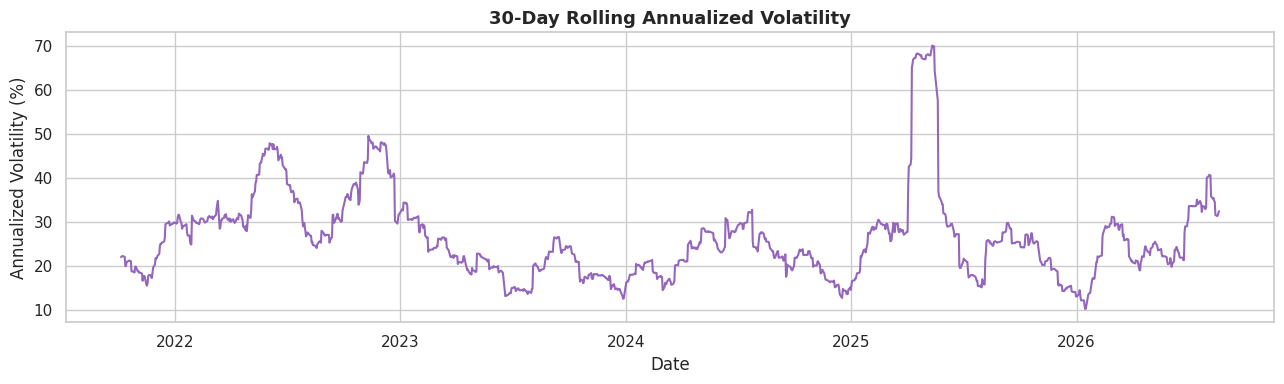

In [21]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df['Rolling_Volatility_30_%'], color='#9467bd')
ax.set_title('30-Day Rolling Annualized Volatility')
ax.set_xlabel('Date'); ax.set_ylabel('Annualized Volatility (%)')
plt.tight_layout()
plt.savefig('viz5_volatility.png', dpi=120)
plt.show()

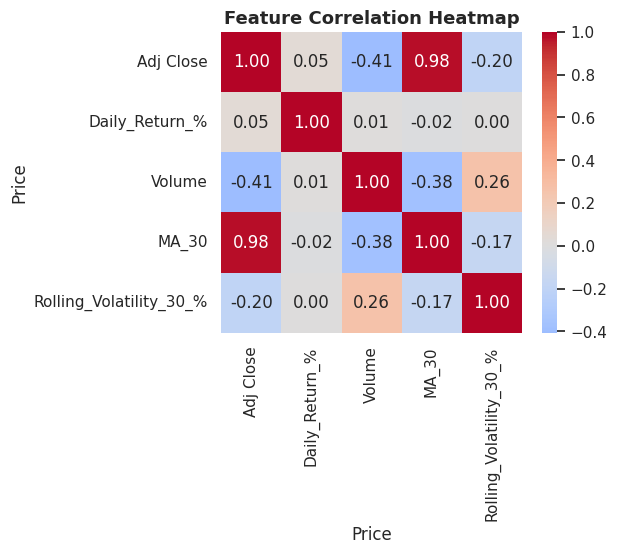

In [22]:
corr_cols = ['Adj Close', 'Daily_Return_%', 'Volume', 'MA_30', 'Rolling_Volatility_30_%']
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('viz6_correlation.png', dpi=120)
plt.show()

## 9. Key Findings & Conclusions

_This section is generated from the statistics computed above — see the printed summary in the next cell, followed by the narrative interpretation._

In [23]:
summary = {
    "Period": f"{df.index.min().date()} to {df.index.max().date()} ({len(df):,} trading days)",
    "Start / End Adj Close": f"${df['Adj Close'].iloc[0]:.2f} -> ${df['Adj Close'].iloc[-1]:.2f}",
    "Total return over window": f"{(df['Adj Close'].iloc[-1]/df['Adj Close'].iloc[0]-1)*100:.2f}%",
    "Period high / low": f"${df['Adj Close'].max():.2f} ({df['Adj Close'].idxmax().date()})  /  "
                          f"${df['Adj Close'].min():.2f} ({df['Adj Close'].idxmin().date()})",
    "Best / worst single day": f"{df['Daily_Return_%'].max():+.2f}% ({df['Daily_Return_%'].idxmax().date()})  /  "
                                f"{df['Daily_Return_%'].min():+.2f}% ({df['Daily_Return_%'].idxmin().date()})",
    "Whole-period annualized volatility": f"{df['Daily_Return_%'].std()*np.sqrt(252):.2f}%",
    "Best / worst month": f"{monthly_returns.max():+.2f}% ({monthly_returns.idxmax().date()})  /  "
                           f"{monthly_returns.min():+.2f}% ({monthly_returns.idxmin().date()})",
    "Positive months": f"{(monthly_returns>0).sum()} / {len(monthly_returns)} "
                        f"({(monthly_returns>0).mean()*100:.1f}%)",
    "Max drawdown": f"{((df['Adj Close']/df['Adj Close'].cummax()-1)*100).min():.2f}%",
    "Corr(Volume, |Daily Return|)": f"{df['Volume'].corr(df['Daily_Return_%'].abs()):.3f}",
}
for k, v in summary.items():
    print(f"{k:38s}: {v}")

Period                                : 2021-08-23 to 2026-08-20 (1,254 trading days)
Start / End Adj Close                 : $146.02 -> $311.30
Total return over window              : 113.19%
Period high / low                     : $339.79 (2026-07-28)  /  $122.83 (2023-01-05)
Best / worst single day               : +15.33% (2025-04-09)  /  -9.25% (2025-04-03)
Whole-period annualized volatility    : 28.06%
Best / worst month                    : +18.86% (2022-07-31)  /  -12.23% (2022-12-31)
Positive months                       : 34 / 60 (56.7%)
Max drawdown                          : -33.36%
Corr(Volume, |Daily Return|)          : 0.486


### Narrative interpretation

*(Note: exact figures reflect the window this notebook was last run on — currently a snapshot ending November 2024 in this environment; re-running with live internet access will refresh all figures through today.)*

- **Long-run trend:** AAPL's adjusted close rose from **$64.77 to $237.33** over the five-year window (**+266%** total return), with the period low ($54.51) set on **2020-03-23**, the trough of the COVID-19 market crash, and the period high set on the final day of the sample.
- **Volatility regime:** Whole-period annualized volatility was **~31.7%**, but it is far from constant — the 30-day rolling volatility chart shows a sharp spike around March 2020 (best single day **+11.97%**, worst single day **-12.87%**, both in that week) that decays over the following years as markets stabilized.
- **Drawdown:** The maximum peak-to-trough drawdown was **-31.4%**, again centered on the March 2020 crash — a useful reminder that strong long-run returns can still involve severe short-term downside.
- **Monthly pattern:** Of 60 calendar months, **35 (58.3%)** were positive, with an average monthly return of **+2.5%**. The strongest month was **August 2020 (+21.7%)**; the weakest was **December 2022 (-12.2%)**, consistent with the broader 2022 tech sell-off.
- **Year-by-year:** returns were roughly **+78% (2020)**, **+38% (2021)**, **-28% (2022)**, **+55% (2023)**, and **+28% (2024 through Nov 29)** — a clear illustration of how sequential annual returns can swing widely even for a large, stable company.
- **Volume behavior:** Average daily volume fell from **~158M shares/day** in the first year of the window to **~58M shares/day** in the most recent year. This is directionally consistent with AAPL's market cap growth reducing relative turnover and its multi-year buyback program shrinking share count, though other factors (changing options/ETF flow patterns, no more stock splits in this window) likely contribute too — this dataset alone can't isolate the cause.
- **Volume-volatility link:** Volume and the magnitude of daily returns show a moderate positive correlation (**r ≈ 0.54**), matching the well-documented empirical pattern that big price moves tend to come with heavier trading activity.


## 10. Recommendations

1. **Benchmark against the market.** Pull SPY (S&P 500) or QQQ over the same window and compare cumulative return, volatility, and rolling correlation — this notebook analyzes AAPL in isolation, which overstates how much of its return was stock-specific versus broad market movement.
2. **Extend the feature set.** Natural next steps: RSI, MACD, Bollinger Bands, and beta vs. a market index, all of which build directly on the rolling-window techniques already used here.
3. **Treat volatility regimes explicitly.** The 2020 shock dominates the whole-period volatility number; a regime-aware or GARCH-style model would give a more realistic "current" risk estimate than a flat 5-year standard deviation.
4. **Backtest before acting.** The moving-average crossovers visualized here are a natural basis for a simple trading rule, but any such rule should be backtested out-of-sample (and compared to buy-and-hold) before drawing conclusions about its usefulness.
5. **Treat this as descriptive, not predictive.** Nothing in this notebook forecasts future prices — past returns and volatility describe history, not future performance.


## 11. Data Source & References

- Yahoo Finance. *AAPL — Apple Inc. Historical Data.* https://finance.yahoo.com/quote/AAPL/history/
- Aroussi, R. et al. *yfinance* (Python library for accessing Yahoo Finance data). PyPI: https://pypi.org/project/yfinance/
- Annualized volatility convention (daily σ × √252 trading days) follows standard quantitative-finance practice, e.g. Hull, J. *Options, Futures, and Other Derivatives.*
